# Multiple Linear Regression

Linear regression is a statistical method used for predictive analysis. It models the relationship between a dependent variable and a single independent variable by fitting a linear equation to the data.

Multiple Linear Regression extends this concept by modelling the relationship between a dependent variable and two or more independent variables. This technique allows us to understand how multiple features collectively affect the outcomes.

## Steps for Multiple Linear Regression

Steps to perform multiple linear regression are similar to that of simple linear Regression but difference comes in the evaluation process. We can use it to find out which factor has the highest influence on the predicted output and how different variables are related to each other. 

### Equation for Multiple Linear Regression

$$y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n$$

Where:
- $y$ is the dependent variable
- $X_1, X_2, \cdots X_n$ are the independent variables
- $\beta_0$ is the intercept
- $\beta_1, \beta_2, \cdots \beta_n$ are the slopes

The goal of the algorithm is to find the best fit line equation that can predict the values based on the independent variables. A regression model learns from the dataset with known X and y values and uses it to predict y values for unknown X.

## Handling Categorical Data with Dummy Variables & Encoding

In multiple regression we often encounter categorical data like gender (male/female), location (urban/rural), color (red/blue/green), etc. Since regression models require numerical inputs, categorical data must be transformed. Here are two common methods:

### Label Encoding vs One-Hot Encoding

**Label Encoding:**
- Assigns integer values: 0, 1, 2, 3, ...
- Example: Color → red=0, green=1, blue=2
- ❌ **Problem**: Model assumes numerical order (0 < 1 < 2), treating categories as ordinal/ranked
- ❌ **Not suitable for regression** - introduces artificial ordering that doesn't exist

**One-Hot Encoding (Dummy Variables):**
- Creates binary (0 or 1) columns for each category
- Example: Color → [red=[1,0,0], green=[0,1,0], blue=[0,0,1]]
- ✅ **Better for regression** - no artificial ordering
- ✅ **Recommended approach** - excludes one category to avoid multicollinearity

### Why One-Hot Encoding Works Better

One-hot encoding treats each category as independent without implying any order or ranking. For example, with gender:
- Male: [1, 0]
- Female: [0, 1]

Each category is represented independently, making it ideal for linear regression models.

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Sample categorical data
sample_data = pd.DataFrame({
    'Color': ['Red', 'Green', 'Blue', 'Red', 'Blue', 'Green']
})

print("Original Categorical Data:")
print(sample_data)
print("\n" + "="*60)

# Method 1: Label Encoding
print("\n1. LABEL ENCODING:")
le = LabelEncoder()
label_encoded = le.fit_transform(sample_data['Color'])
print(f"Encoded values: {label_encoded}")
print("Problem: Model thinks Blue(2) > Green(1) > Red(0) - FALSE ORDERING!\n")

# Method 2: One-Hot Encoding
print("2. ONE-HOT ENCODING:")
one_hot = pd.get_dummies(sample_data['Color'], drop_first=True)
print(one_hot)
print("✓ Each category is independent - no artificial ordering")
print("✓ drop_first=True prevents multicollinearity")

Original Categorical Data:
   Color
0    Red
1  Green
2   Blue
3    Red
4   Blue
5  Green


1. LABEL ENCODING:
Encoded values: [2 1 0 2 0 1]
Problem: Model thinks Blue(2) > Green(1) > Red(0) - FALSE ORDERING!

2. ONE-HOT ENCODING:
   Green    Red
0  False   True
1   True  False
2  False  False
3  False   True
4  False  False
5   True  False
✓ Each category is independent - no artificial ordering
✓ drop_first=True prevents multicollinearity


## Multicollinearity in Multiple Linear Regression

Multicollinearity arises when two or more independent variables are highly correlated with each other. This can make it difficult to find the individual contribution of each variable to the dependent variable.

To detect multicollinearity we can use:

1. **Correlation Matrix**: A correlation matrix helps to find relationships between independent variables. High correlations (close to 1 or -1) suggest multicollinearity.
2. **VIF (Variance Inflation Factor)**: VIF quantifies how much the variance of a regression coefficient increases if predictors are correlated. A high VIF typically above 10 indicates multicollinearity.

## Assumptions of Multiple Regression Model

Similar to simple linear regression we have some assumptions in multiple linear regression which are as follows:

1. **Linearity**: Relationship between dependent and independent variables should be linear.
2. **Homoscedasticity**: Variance of errors should remain constant across all levels of independent variables.
3. **Multivariate Normality**: Residuals should follow a normal distribution.
4. **No Multicollinearity**: Independent variables should not be highly correlated.

## Gradient Descent in Multiple Linear Regression

Gradient Descent is an optimization algorithm used to find the best coefficients ($\beta$ values) that minimize prediction errors.

### Cost Function (Mean Squared Error)

The goal is to minimize the MSE:

$$J(\beta) = \frac{1}{2m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 = \frac{1}{2m} \sum_{i=1}^{m} (y_i - (\beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + \cdots + \beta_n X_{ni}))^2$$

Where $m$ is the number of samples.

**Why $\frac{1}{2m}$ instead of $\frac{1}{m}$?**

The factor of $\frac{1}{2}$ is a mathematical convenience:
- When taking the derivative of $(y - \hat{y})^2$, we get $2(y - \hat{y})$
- The $\frac{1}{2}$ cancels out the 2 from the derivative, giving cleaner gradient equations
- It doesn't affect optimization (just scales the cost) - we minimize both the same way
- This is a common convention in machine learning for mathematical elegance

### Gradient Calculation

The gradient (partial derivative) for each coefficient is:

$$\frac{\partial J}{\partial \beta_j} = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i) \cdot (-X_{ji})$$

Or simply:
$$\frac{\partial J}{\partial \beta_j} = \frac{-1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i) \cdot X_{ji}$$

### Gradient Descent Update Rule

Coefficients are updated iteratively using:

$$\beta_j := \beta_j - \alpha \cdot \frac{\partial J}{\partial \beta_j}$$

Where $\alpha$ (alpha) is the **learning rate** - a small value (typically 0.01-0.1) that controls step size.

### How It Works

1. Initialize coefficients (usually to 0)
2. Calculate predictions: $\hat{y} = \beta X$
3. Calculate gradient: how much to change each $\beta$
4. Update coefficients in opposite direction of gradient
5. Repeat until convergence (gradient ≈ 0)

## Implementation of Multiple Linear Regression Model

We will use the California Housing dataset which includes features such as median income, average rooms and the target variable, house prices.

### Step 1: Importing Libraries

We will be using numpy, pandas, matplotlib and scikit-learn for this.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

### Step 2: Loading Dataset

Load the California Housing dataset from sklearn.datasets. The dataset contains features such as median income, average rooms stored in X and the target i.e house prices is stored in y.

In [2]:
california_housing = fetch_california_housing()

X = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
y = pd.Series(california_housing.target)

print("Dataset shape:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst few rows of X:\n{X.head()}")

Dataset shape:
X shape: (20640, 8)
y shape: (20640,)

First few rows of X:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


### Step 3: Selecting Features for Visualization

Choose two features MedInc (median income) and AveRooms (average rooms) to simplify visualization in two dimensions.

In [3]:
X = X[['MedInc', 'AveRooms']]
print("Selected features:")
print(X.head())

Selected features:
   MedInc  AveRooms
0  8.3252  6.984127
1  8.3014  6.238137
2  7.2574  8.288136
3  5.6431  5.817352
4  3.8462  6.281853


### Step 4: Train-Test Split

We will use 80% data for training and 20% for testing.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 16512
Test set size: 4128


### Step 5: Initializing and Training Model

Create a multiple linear regression model using LinearRegression from scikit-learn and train it on the training data.

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Intercept (β₀): {model.intercept_:.4f}")
print(f"Coefficients (β₁, β₂): {model.coef_}")

Model trained successfully!
Intercept (β₀): 0.5973
Coefficients (β₁, β₂): [ 0.43626089 -0.04017161]


### Step 6: Making Predictions

Using the trained model to predict house prices on the test data.

In [6]:
y_pred = model.predict(X_test)

# Display sample predictions vs actual values
comparison = pd.DataFrame({
    'Actual': y_test.values[:5],
    'Predicted': y_pred[:5],
    'Difference': y_test.values[:5] - y_pred[:5]
})
print("Sample Predictions vs Actual Values:")
print(comparison)

Sample Predictions vs Actual Values:
    Actual  Predicted  Difference
0  0.47700   1.162302   -0.685302
1  0.45800   1.499135   -1.041135
2  5.00001   1.955731    3.044279
3  2.18600   2.852755   -0.666755
4  2.78000   2.001677    0.778323


### Step 7: Visualizing Best Fit Line in 3D

Plot a 3D graph where blue points represent actual house prices based on MedInc and AveRooms and the red surface shows the best-fit plane predicted by the model. This visualization helps us to understand how these two features influence the predicted house prices.

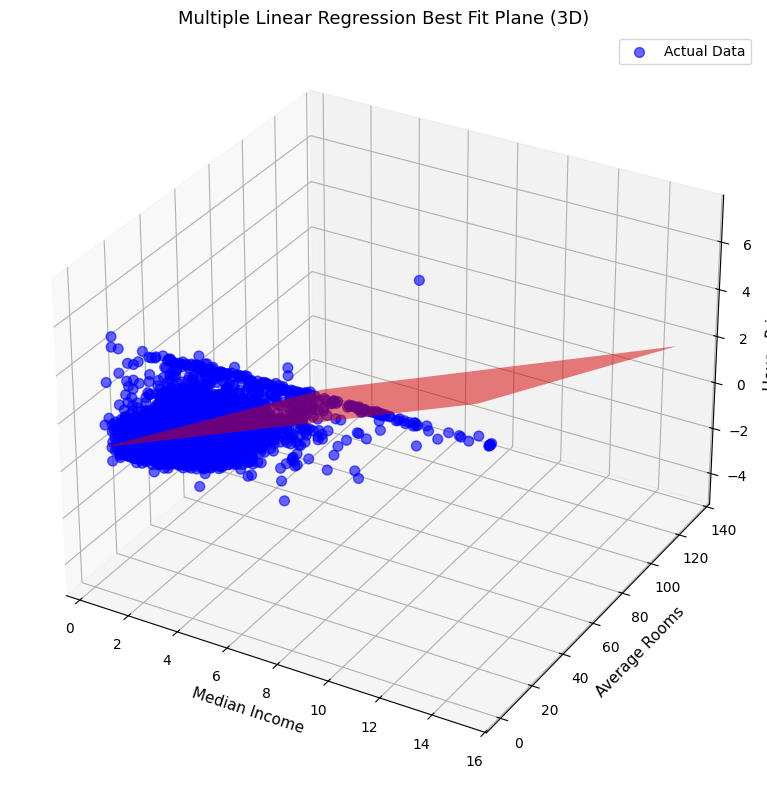

3D visualization of Multiple Linear Regression completed!


In [8]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot actual data points
ax.scatter(X_test['MedInc'], X_test['AveRooms'],
           y_test, color='blue', label='Actual Data', s=50, alpha=0.6)

# Create mesh for the best fit plane
x1_range = np.linspace(X_test['MedInc'].min(), X_test['MedInc'].max(), 100)
x2_range = np.linspace(X_test['AveRooms'].min(), X_test['AveRooms'].max(), 100)
x1, x2 = np.meshgrid(x1_range, x2_range)

# Predict z values for the mesh
z = model.predict(pd.DataFrame(np.c_[x1.ravel(), x2.ravel()], columns=['MedInc', 'AveRooms'])).reshape(x1.shape)

# Plot the surface
ax.plot_surface(x1, x2, z, color='red', alpha=0.5, rstride=100, cstride=100)

ax.set_xlabel('Median Income', fontsize=11)
ax.set_ylabel('Average Rooms', fontsize=11)
ax.set_zlabel('House Price', fontsize=11)
ax.set_title('Multiple Linear Regression Best Fit Plane (3D)', fontsize=13)
ax.legend()

plt.tight_layout()
plt.show()

print("3D visualization of Multiple Linear Regression completed!")

## Summary

Multiple Linear Regression effectively captures how several factors together influence a target variable which helps in providing a practical approach for predictive modeling in real-world scenarios. 

Key Takeaways:
- Multiple Linear Regression extends simple linear regression to handle multiple features
- The model finds the best-fit hyperplane (in this case a plane in 3D) that minimizes prediction errors
- Proper handling of categorical variables through dummy encoding ensures all data can be used
- Checking for multicollinearity is crucial to ensure reliable coefficient estimates
- Visualization in 3D helps understand the relationship between variables and the response
- The model equation allows us to understand the individual contribution (coefficient) of each feature